## Exercise 6: Simulation of 2D Wave Equation

This exercise covers the following aspects:

- presenting you with an implementation of the 2D acoustic wave equation
- allowing you to explore the benefits of using high-order finite-difference operators
- understanding the concepts of stability (Courant criterion)
- exploration of numerical dispersion and numerical grid anisotropy
- changing the earth model and exploring some effects of structural heterogeneities (e.g., fault zones)

---

## Basic Equations

The acoustic wave equation in 2D is 
$$
\ddot{p}(x,z,t) \ = \ c(x,z)^2 (\partial_x^2 p(x,z,t) + \partial_z^2 p(x,z,t)) \ + s(x,z,t)
$$

and we replace the time-dependent (upper index time, lower indices space) part by

$$
 \frac{p_{j,k}^{n+1} - 2 p_{j,k}^n + p_{j,k}^{n-1}}{\mathrm{d}t^2} \ = \ c_j^2 ( \partial_x^2 p + \partial_z^2 p) \ + s_{j,k}^n
$$

solving for $p_{j,k}^{n+1}$. 
The extrapolation scheme is
$$
p_{j,k}^{n+1} \ = \ c_j^2 \mathrm{d}t^2 \left[ \partial_x^2 p + \partial_z^2 p \right]
+ 2p_{j,k}^n - p_{j,k}^{n-1} + \mathrm{d}t^2 s_{j,k}^n
$$
The  space derivatives are determined by 

$$
\partial_x^2 p \ = \ \frac{p_{j+1,k}^{n} - 2 p_{j,k}^n + p_{j-1,k}^{n}}{\mathrm{d}x^2}
$$
$$
\partial_z^2 p \ = \ \frac{p_{j,k+1}^{n} - 2 p_{j,k}^n + p_{j,k-1}^{n}}{\mathrm{d}z^2} 
$$

---

## Getting started
Before you start it is good practice to immediately make a copy of the original notebook (e.g., X_orig.ipynb). 
Run the simulation code. Relate the time extrapolation loop with the numerical algorithm we developed in the course. Understand the input parameters for the simulation and the plots that are generated. Modify source and receiver locations and observe the effects on the seismograms. 

---

This notebook is based on the supplementary material 
to [Computational Seismology: A Practical Introduction](https://global.oup.com/academic/product/computational-seismology-9780198717416?cc=de&lang=en&#), Oxford University Press, 2016.

The notebook has been modifed by Tarlan Khoveiledy and Islam Fadel for the exercise purpose.

In [1]:
# 1) Install dependencies if missing
import sys, subprocess, importlib

def ensure(pkg, import_name=None):
    name = import_name or pkg
    try:
        importlib.import_module(name)
        print(f"[ok] {pkg} already installed")
    except Exception:
        print(f"[info] Installing {pkg} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
        importlib.import_module(name)
        print(f"[ok] {pkg} installed")


pkgs = ["os", "ipympl", "numpy", "matplotlib"]

for pkg in pkgs:
    ensure(pkg)

[ok] os already installed
[ok] ipympl already installed
[ok] numpy already installed
[ok] matplotlib already installed


# Import required libraries

In the next cell, we will import the required packages.

In [2]:
# Configuration
import ipympl
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Define the parameters and constants needed for the exercise.
The cell below allows you to plot source time function, seismic velocites, and the resulting seismograms in windows inside the notebook. Remember to rerun after you simulated again!

Courant Criterion eps:
0.3


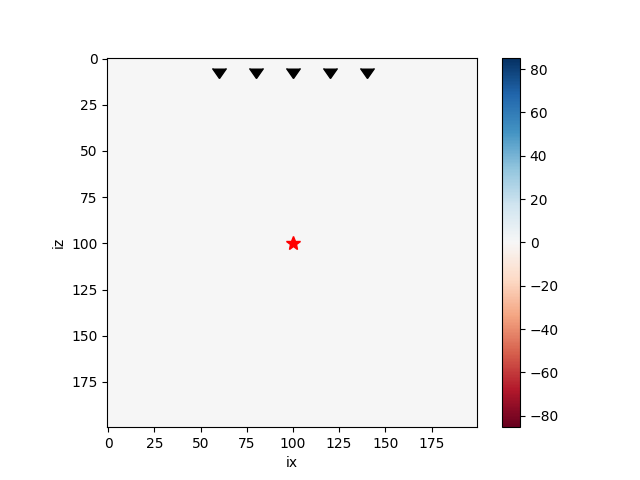

In [3]:


nx = 200      # grid points in x
nz = 200      # grid points in z
nt = 750      # number of time steps
dx = 10.0     # grid increment in x
dt = 0.001    # Time step
c0 = 3000.0   # velocity (can be an array)
isx = nx // 2 # source index x
isz = nz // 2 # source index z
ist = 100     # shifting of source time function
f0 = 100.0    # dominant frequency of source (Hz)
isnap = 10    # snapshot frequency
T = 1.0 / f0  # dominant period
nop = 3       # length of operator

# Model type, available are "homogeneous", "fault_zone",
# "surface_low_velocity_zone", "random", "topography", "slab"
model_type = "surface_low_velocity_zone"

# Receiver locations
irx = np.array([60, 80, 100, 120, 140])
irz = np.array([5, 5, 5, 5, 5])
seis = np.zeros((len(irx), nt))

# Initialize pressure at different time steps and the second
# derivatives in each direction
p    = np.zeros((nz, nx))
pold = np.zeros((nz, nx))
pnew = np.zeros((nz, nx))
pxx  = np.zeros((nz, nx))
pzz  = np.zeros((nz, nx))

# Initialize velocity model
c = np.zeros((nz, nx))

if model_type == "homogeneous":
    c += c0
elif model_type == "fault_zone":
    c += c0
    c[:, nx // 2 - 5: nx // 2 + 5] *= 0.8
elif model_type == "surface_low_velocity_zone":
    c += c0
    c[1:10, :] *= 0.8
elif model_type == "random":
    pert = 0.4
    r = 2.0 * (np.random.rand(nz, nx) - 0.5) * pert
    c += c0 * (1 + r)
elif model_type == "topography":
    c += c0
    c[0:10,  10:50]   = 0
    c[0:10,  105:115] = 0
    c[0:30,  145:170] = 0
    c[10:40, 20:40]   = 0
    c[0:15,  50:105] *= 0.8
elif model_type == "slab":
    c += c0
    c[110:125, 0:125] = 1.4 * c0
    for i in range(110, 180):
        c[i, i-5: i+15] = 1.4 * c0
else:
    raise NotImplementedError

cmax = c.max()

# Source time function Gaussian, nt + 1 as we lose the last one by diff
src = np.empty(nt + 1)
for it in range(nt):
    src[it] = np.exp(-1.0 / T ** 2 * ((it - ist) * dt) ** 2)
src = np.diff(src) / dt
src[nt - 1] = 0

v = max([np.abs(src.min()), np.abs(src.max())])

# Initialize plot
fig, ax = plt.subplots()
image = ax.imshow(pnew, interpolation='nearest', animated=True,
                  vmin=-v, vmax=+v, cmap=plt.cm.RdBu)
for x, z in zip(irx, irz):
    ax.plot(x, z, marker=11, color='black', markersize=10)
ax.plot(isx, isz, 'r*', markersize=10)
plt.colorbar(image, ax=ax)
ax.set_xlabel('ix')
ax.set_ylabel('iz')

ir = np.arange(len(irx))

print("Courant Criterion eps:")
print(cmax * dt / dx)

def update(it):
    global p, pold, pxx, pzz

    # Calculate spatial derivatives
    if nop == 3:
        for i in range(1, nx - 1):
            pzz[:, i] = p[:, i + 1] - 2 * p[:, i] + p[:, i - 1]
        for j in range(1, nz - 1):
            pxx[j, :] = p[j - 1, :] - 2 * p[j, :] + p[j + 1, :]

    elif nop == 5:
        for i in range(2, nx - 2):
            pzz[:, i] = -1./12*p[:,i+2]+4./3*p[:,i+1]-5./2*p[:,i]+4./3*p[:,i-1]-1./12*p[:,i-2]
        for j in range(2, nz - 2):
            pxx[j, :] = -1./12*p[j+2,:]+4./3*p[j+1,:]-5./2*p[j,:]+4./3*p[j-1,:]-1./12*p[j-2,:]

    pxx /= dx ** 2
    pzz /= dx ** 2

    # Time extrapolation
    pnew = 2 * p - pold + dt ** 2 * c ** 2 * (pxx + pzz)
    pnew[isz, isx] += src[it]

    # Save seismograms
    seis[ir, it] = pnew[irz[ir], irx[ir]]

    # Update plot every isnap steps
    if it % isnap == 0:
        image.set_data(pnew)
        ax.set_title("Max P: %.2f" % pnew.max())

    # Shift pressure fields
    pold = p.copy()
    p = pnew.copy()

    return [image]

ani = FuncAnimation(fig, update, frames=nt, interval=20, blit=False, repeat=False)
plt.show()

# Visualize the model and the calculated signals

In the following cell, we visulaize the model used in the previous simulation and also plot the signal observed at the receivers. Remeber to re-run after you change the model in the previous cell.

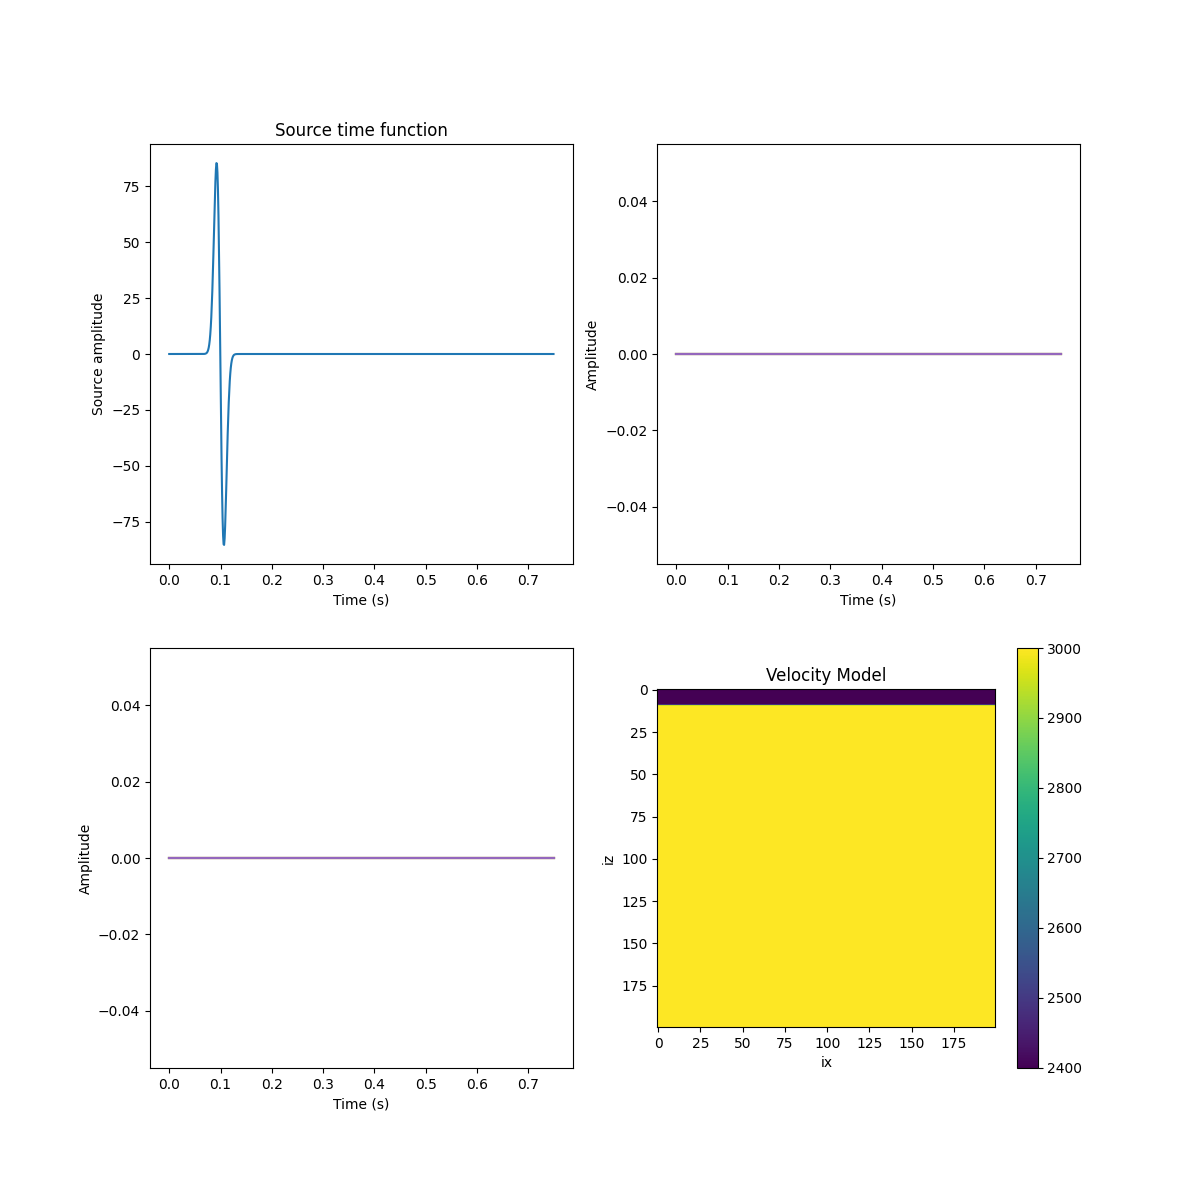

In [4]:
plt.ioff()
plt.figure(figsize=(12, 12))

plt.subplot(221)
time = np.arange(nt) * dt
plt.plot(time, src)
plt.title('Source time function')
plt.xlabel('Time (s)')
plt.ylabel('Source amplitude')

plt.subplot(222)
ymax = seis.ravel().max()
for ir in range(len(seis)):
    plt.plot(time, seis[ir, :] + ymax * ir)
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')

plt.subplot(223)
ymax = seis.ravel().max()
for ir in range(len(seis)):
    plt.plot(time, seis[ir, :] + ymax * ir)
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')

plt.subplot(224)
plt.title('Velocity Model')
plt.imshow(c)
plt.xlabel('ix')
plt.ylabel('iz')
plt.colorbar()

plt.show()

## Extra Tasks

#### Stability: 
The eps parameter represents the Courant criterion defined as $eps = (velocity * dt) / dx$. With this information you can calculate the maximum possible, stable time step. You can use it Determine numerically the stability limit of the code as accurately as possible by increasing the time step. Observe the max value of the pressure field and the evolution in time in the case of stable and unstable simulations.

#### High-order operators:
Check the reuslts for different length of the operator (length of the operator 3 and 5 nop) and investiagte how this impact the simulation results. 
Extend the code by adding the option to use a 5-point difference operator (see problem 1 of exercise sheet). Compare simulations with  different length of operators the 3-point and 5-point operator. Is the stability limit still the same? Estimate the number of points per wavelength and investigate the accuracy of the simulation by looking for signs of numerical dispersion in the resulting seismograms. 

#### Heterogeneous models
The finite-difference method is powerful and allows varying the internal structure of the model. Here we can only modify the velocity c that can vary at each grid point (any restrictions?). Try the following suggestions: Investigate the influence of the structure by analysing the snapshots and the seismograms.
Check the slab, fault and topography model options and visualize the results
Vary the velocity in the case of the low velocity layer and investigate the results. How the amplitudes compare to each other.
